In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [6]:
df=pd.read_csv("Advertising.csv")
df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [8]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [11]:
df.shape

(200, 5)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [7]:
df.tail()

,Unnamed: 0,TV,Radio,Newspaper,Sales
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


In [14]:
df.sample(5)


,Unnamed: 0,TV,Radio,Newspaper,Sales
181,182,218.5,5.4,27.4,12.2
84,85,213.5,43.0,33.8,21.7
57,58,136.2,19.2,16.6,13.2
27,28,240.1,16.7,22.9,15.9
72,73,26.8,33.0,19.3,8.8


In [19]:
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

<Axes: xlabel='TV', ylabel='Count'>

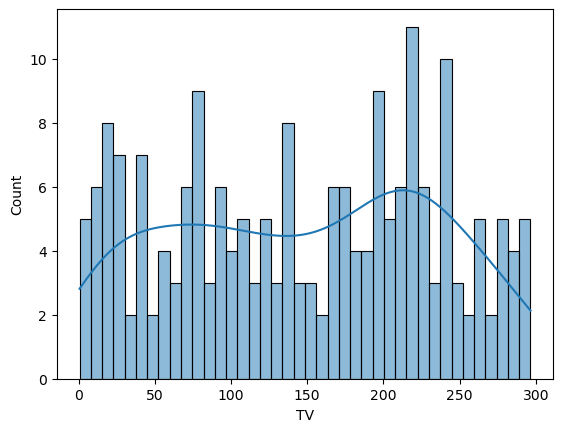

In [32]:
sns.histplot(x=df['TV'],kde=True,bins=40)

<Axes: xlabel='Radio', ylabel='Count'>

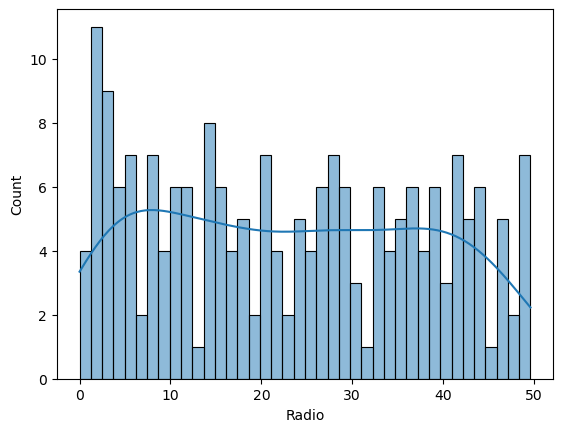

In [31]:
sns.histplot(x=df['Radio'],kde=True,bins=40)

<Axes: xlabel='Newspaper', ylabel='Count'>

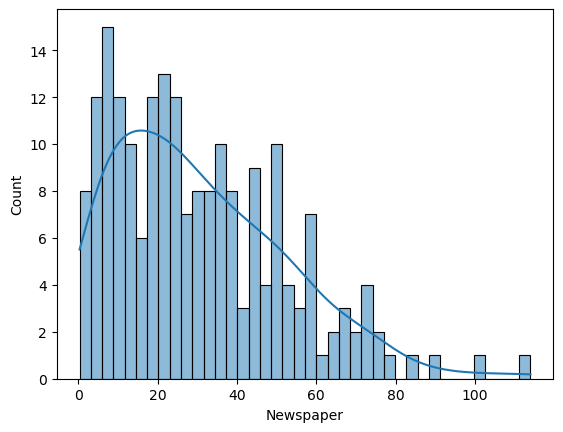

In [30]:
sns.histplot(x=df['Newspaper'],kde=True,bins=40)

<Axes: xlabel='Sales', ylabel='Count'>

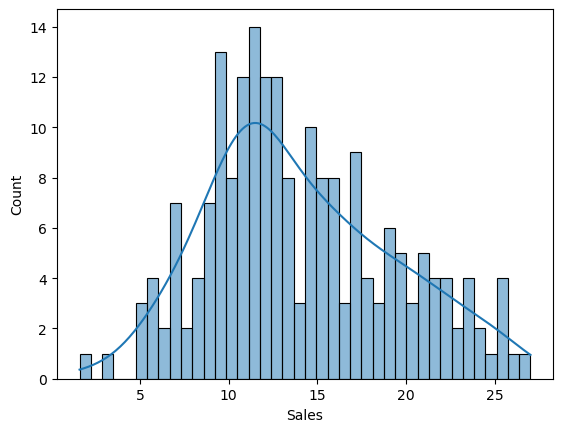

In [29]:
sns.histplot(x=df['Sales'],kde=True,bins=40)

In [35]:
df['TV'].skew()

np.float64(-0.06985336213274573)

In [36]:
df['Radio'].skew()

np.float64(0.09417463149664404)

In [37]:
df['Newspaper'].skew()

np.float64(0.8947204074986175)

In [38]:
df['Sales'].skew()

np.float64(0.4075714250767127)

The graphs are classified into three types
   1. Right Side
   2. Left Side
   3. Normal
- Using the "skew()" function, the values of the graphs are estimated from a certain range.
- If the range varies between "-0.5 to 0.5" in Consider it as a Normal graph

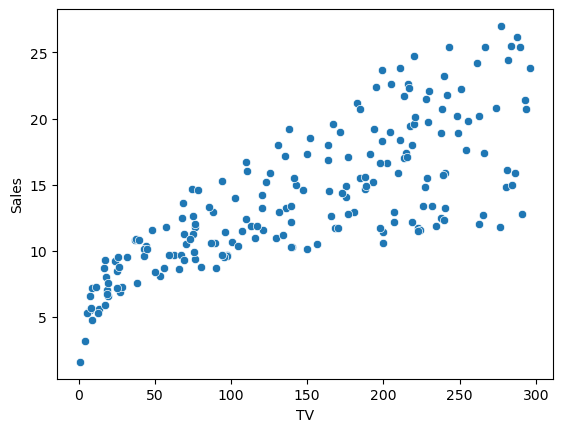

In [39]:
sns.scatterplot(x=df['TV'],y=df['Sales'])
plt.show()

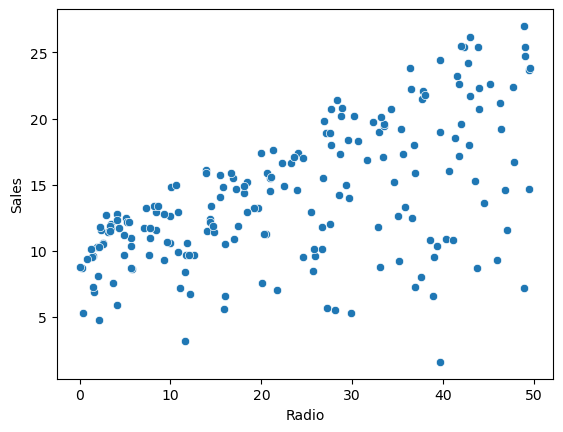

In [40]:
sns.scatterplot(x=df['Radio'],y=df['Sales'])
plt.show()

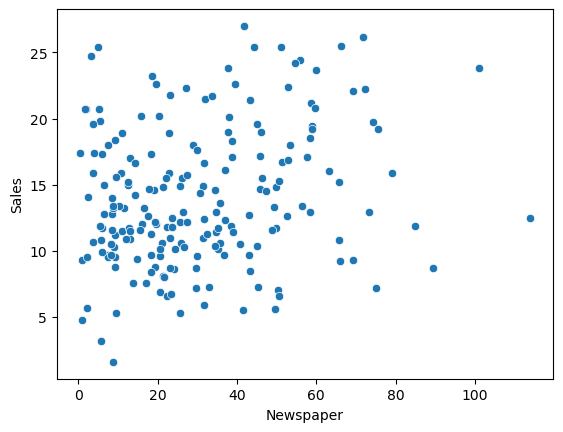

In [41]:
sns.scatterplot(x=df['Newspaper'],y=df['Sales'])
plt.show()

In [43]:
df.corr()

,Unnamed: 0,TV,Radio,Newspaper,Sales
Unnamed: 0,1.000000,0.017715,-0.110680,-0.154944,-0.051616
TV,0.017715,1.000000,0.054809,0.056648,0.782224
Radio,-0.110680,0.054809,1.000000,0.354104,0.576223
Newspaper,-0.154944,0.056648,0.354104,1.000000,0.228299
Sales,-0.051616,0.782224,0.576223,0.228299,1.000000


TV – Sales have a strong positive correlation.
Radio – Sales have a moderate positive correlation.
Newspaper – Sales have a weak positive correlation.
TV – Radio have a very weak positive correlation.
TV – Newspaper have a very weak positive correlation.
Radio – Newspaper have a weak positive correlation.

<Axes: >

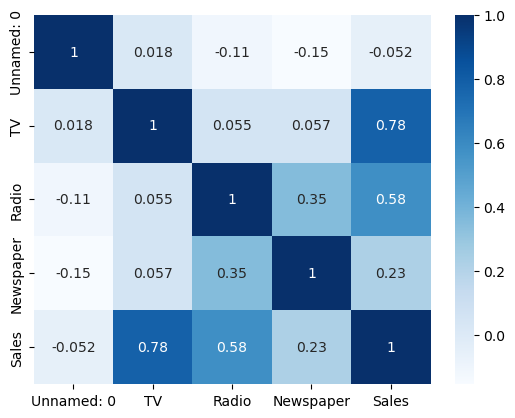

In [48]:
# dark colour =  strong relationship
# light colour = weak relationship
sns.heatmap(df.corr(),annot=True, cmap='Blues')

In [53]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [10]:
#step 1: Indepenent and dependent variable creation
X=df[['TV']]
y=df.Sales

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=4)

In [14]:
print(len(X_test))
print(len(X_train))

40
160


In [15]:
#step3 Creating model
from sklearn.linear_model import LinearRegression
LR=LinearRegression()
LR.fit(X_train,y_train)
y_predict=LR.predict(X_test)

In [18]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,root_mean_squared_error
r2score=r2_score(y_test,y_predict)
r2score

0.46138746336817515

In [19]:
print("MSE : ",mean_squared_error(y_test,y_predict))
print("MAE : ",mean_absolute_error(y_test,y_predict))
print("RMSE : ",root_mean_squared_error(y_test,y_predict))

MSE :  13.06226628830567
MAE :  2.990565035759226
RMSE :  3.6141757412037494


In [20]:
X=df[['Radio']]
y=df.Sales

In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=4)

In [22]:
print(len(X_test))
print(len(X_train))

40
160


In [23]:
#step3 Creating model
from sklearn.linear_model import LinearRegression
LR=LinearRegression()
LR.fit(X_train,y_train)
y_predict=LR.predict(X_test)

In [24]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,root_mean_squared_error
r2score=r2_score(y_test,y_predict)
r2score

0.37864501183785726

In [25]:
print("MSE : ",mean_squared_error(y_test,y_predict))
print("MAE : ",mean_absolute_error(y_test,y_predict))
print("RMSE : ",root_mean_squared_error(y_test,y_predict))

MSE :  15.068910882943161
MAE :  3.268917036469783
RMSE :  3.881869508747449


In [26]:
X=df[['Newspaper']]
y=df.Sales

In [27]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=4)

In [28]:
print(len(X_test))
print(len(X_train))

40
160


In [29]:
#step3 Creating model
from sklearn.linear_model import LinearRegression
LR=LinearRegression()
LR.fit(X_train,y_train)
y_predict=LR.predict(X_test)

In [30]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,root_mean_squared_error
r2score=r2_score(y_test,y_predict)
r2score

-0.11728796161004906

In [31]:
print("MSE : ",mean_squared_error(y_test,y_predict))
print("MAE : ",mean_absolute_error(y_test,y_predict))
print("RMSE : ",root_mean_squared_error(y_test,y_predict))

MSE :  27.096125475528662
MAE :  3.992290912504232
RMSE :  5.205393882841976


In [33]:
X=df[['TV','Radio','Newspaper']]
y=df.Sales

In [34]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=4)

In [35]:
print(len(X_test))
print(len(X_train))

40
160


In [36]:
#step3 Creating model
from sklearn.linear_model import LinearRegression
LR=LinearRegression()
LR.fit(X_train,y_train)
y_predict=LR.predict(X_test)

In [37]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,root_mean_squared_error
r2score=r2_score(y_test,y_predict)
r2score

0.9085774752313167

In [38]:
print("MSE : ",mean_squared_error(y_test,y_predict))
print("MAE : ",mean_absolute_error(y_test,y_predict))
print("RMSE : ",root_mean_squared_error(y_test,y_predict))

MSE :  2.217151072541896
MAE :  1.2114892606469103
RMSE :  1.4890100982001082
